NAME: ALOK KUMAR MAVI

SECTION: B

ROLL.NO.: 05

CU ID: CU240251681

LAB SHEET - 04

=== Dataset Summary ===
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4




/tmp/ipykernel_540/2987805313.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_bill, x='day', y='total_bill', palette='viridis', ax=axes[0, 0])
/tmp/ipykernel_540/2987805313.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset, x='time', y='tip', palette='Set2', ax=axes[1, 1])


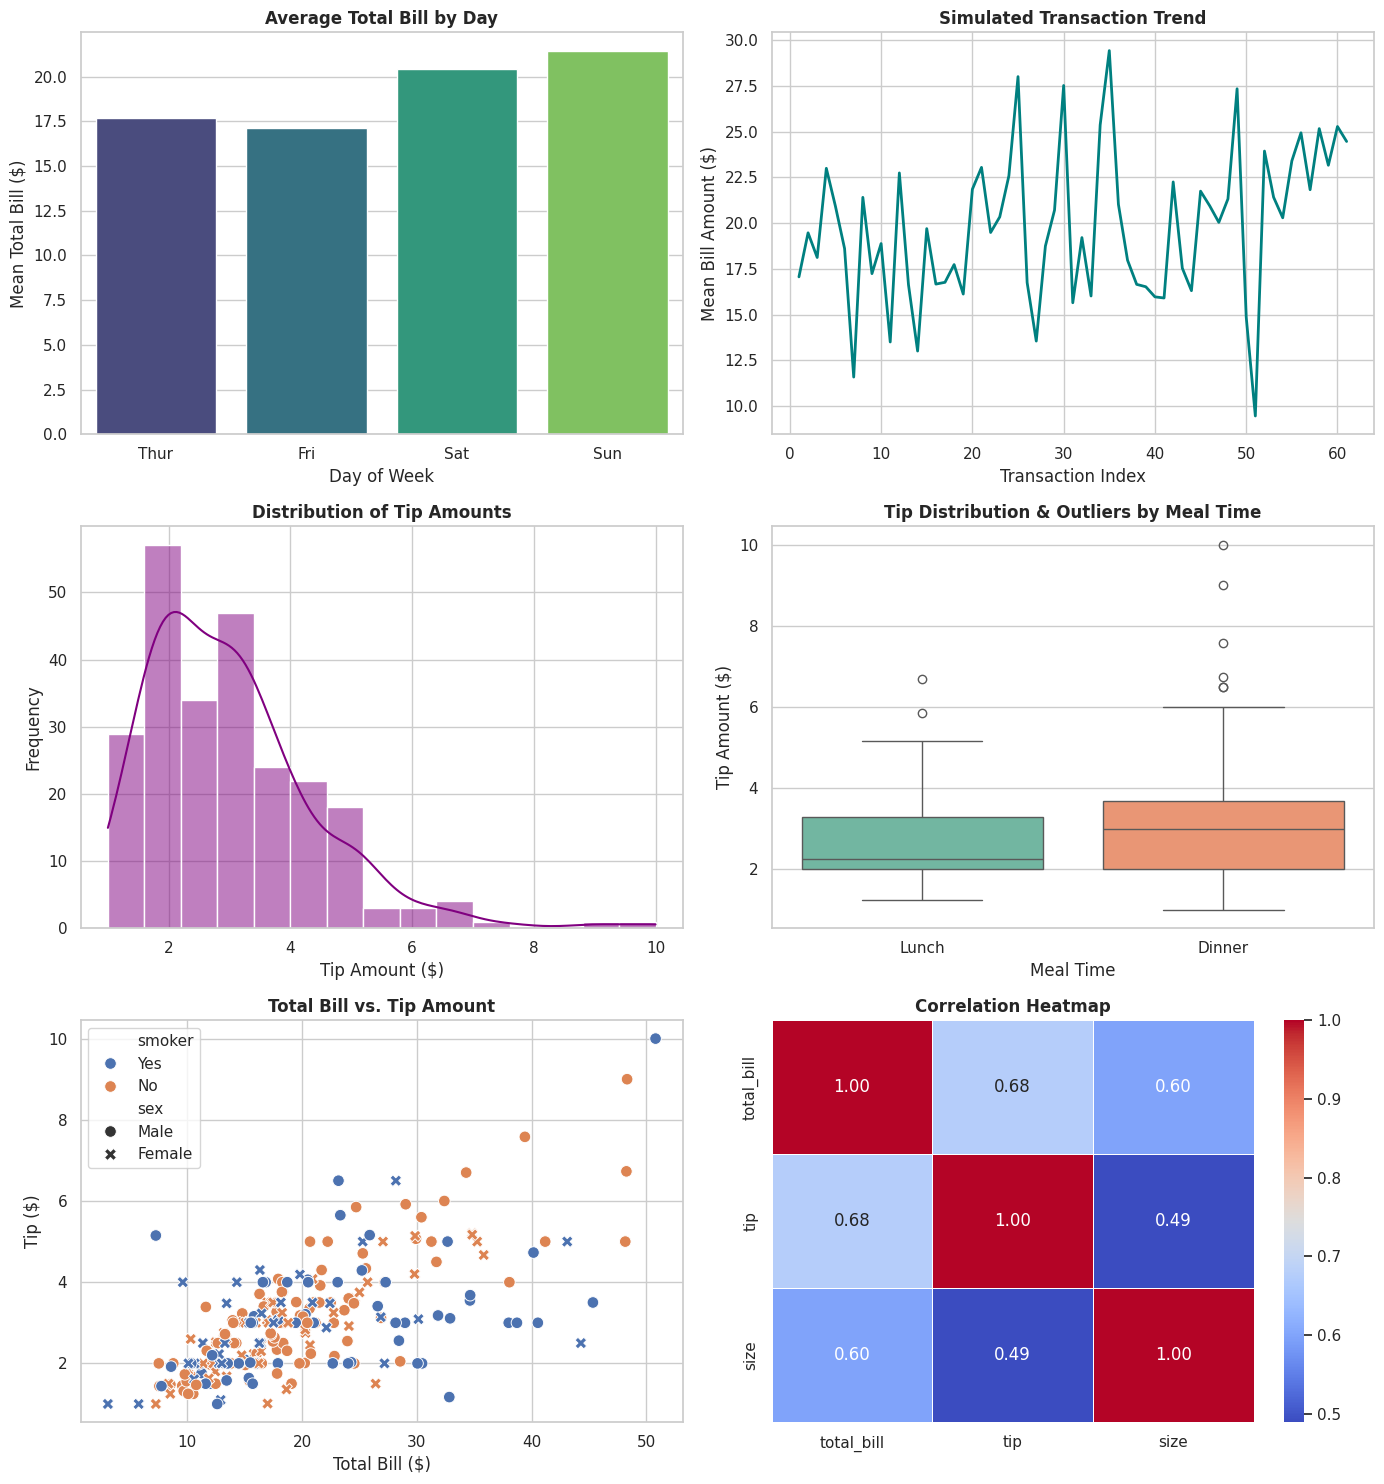

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Step 1 & 2: Load Dataset (Tips Dataset via Seaborn)
dataset = sns.load_dataset('tips')

# Display core info
print("=== Dataset Summary ===")
print(dataset.head())
print("\n" + "="*50 + "\n")

# Setup multi-plot layout canvas
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Step 3: Bar Chart - Average Total Bill by Day of Week
day_bill = dataset.groupby('day', observed=True)['total_bill'].mean().reset_index()
sns.barplot(data=day_bill, x='day', y='total_bill', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title("Average Total Bill by Day", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Day of Week")
axes[0, 0].set_ylabel("Mean Total Bill ($)")

# Step 4: Line Chart - Simulated Trend of Total Bill Over Time
dataset['simulated_time'] = np.tile(np.arange(1, 62), len(dataset) // 61 + 1)[:len(dataset)]
time_trend = dataset.groupby('simulated_time')['total_bill'].mean().reset_index()
sns.lineplot(data=time_trend, x='simulated_time', y='total_bill', color='teal', linewidth=2, ax=axes[0, 1])
axes[0, 1].set_title("Simulated Transaction Trend", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Transaction Index")
axes[0, 1].set_ylabel("Mean Bill Amount ($)")

# Step 5: Histogram - Distribution of Tip Amounts
sns.histplot(dataset['tip'], kde=True, color='purple', bins=15, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Tip Amounts", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Tip Amount ($)")
axes[1, 0].set_ylabel("Frequency")

# Step 6: Box Plot - Tip Distribution Across Meal Times (Outlier Detection)
sns.boxplot(data=dataset, x='time', y='tip', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title("Tip Distribution & Outliers by Meal Time", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Meal Time")
axes[1, 1].set_ylabel("Tip Amount ($)")

# Step 7: Scatter Plot - Total Bill vs. Tip Amount
sns.scatterplot(data=dataset, x='total_bill', y='tip', hue='smoker', style='sex', palette='deep', s=70, ax=axes[2, 0])
axes[2, 0].set_title("Total Bill vs. Tip Amount", fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel("Total Bill ($)")
axes[2, 0].set_ylabel("Tip ($)")

# Step 8: Correlation Heatmap
numeric_df = dataset.select_dtypes(include=[np.number]).drop(columns=['simulated_time'], errors='ignore')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[2, 1])
axes[2, 1].set_title("Correlation Heatmap", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### Questions and Answers

**1. Why is data visualization considered an essential component of data analytics?**

* **Cognitive Efficiency:** Humans process visual information faster than tabular raw data, making patterns, anomalies, and structural trends immediately visible.
* **Exploratory Analysis:** Aids in discovering underlying data distributions, variance, correlations, and outliers during initial preprocessing stages.
* **Communication:** Bridges technical analytical findings with non-technical stakeholders to drive data-informed decisions.

**2. Differentiate between Matplotlib and Seaborn. Which library is more suitable for statistical visualizations and why?**

* **Matplotlib:** A low-level, procedural plotting library providing fine-grained control over every element of a figure (canvas, axes, ticks, spines). It requires verbose code to render complex graphics.
* **Seaborn:** A high-level declarative library built on top of Matplotlib that integrates directly with Pandas DataFrames and features built-in statistical functions (KDE, confidence intervals, regression lines).
* **Verdict:** Seaborn is more suitable for statistical visualizations because it automates statistical aggregation, grouping, and color mapping using concise syntax.

**3. Which type of chart would you choose to compare sales across different regions? Justify your answer.**

* **Chart Choice:** Bar Chart (or Horizontal Bar Chart).
* **Justification:** Bar charts visually map categorical variables (regions) to numerical lengths (sales volumes) along a clear baseline, enabling accurate side-by-side comparative analysis across distinct groups.

**4. What information can be obtained from a histogram and a box plot?**

* **Histogram:** Shows the continuous frequency distribution, underlying shape (e.g., normal, skewed, bimodal), central tendency, spread, and modality of a single variable.
* **Box Plot:** Displays five-number summaries (minimum, lower quartile $Q_1$, median $Q_2$, upper quartile $Q_3$, maximum), interquartile range (IQR), skewness, and explicitly flags statistical outliers falling outside $1.5 \times \text{IQR}$.

**5. Explain the purpose of a scatter plot. How does it help in identifying relationships between variables?**

* **Purpose:** Displays individual data points plotted along Cartesian coordinates for two continuous numerical variables.
* **Relationship Detection:** Reveals the direction (positive/negative), form (linear/non-linear), strength, and clustering of bivariate relationships, as well as bivariate outliers.

**6. What is a correlation heatmap? How can it assist in feature selection for machine learning?**

* **Definition:** A 2D matrix grid that visually displays Pearson correlation coefficients between numeric variables using color scales.
* **Feature Selection Role:** Helps identify **multicollinearity** (high correlation between independent features), allowing redundancy reduction by dropping overlapping variables before model training.

**7. Why is chart customization (titles, labels, legends, colors) important in data visualization?**

* **Contextual Clarity:** Prevents misinterpretation by explicitly defining axis metrics, scale units, and legend categories.
* **Accessibility & Focus:** Improves readability using proper font contrast, color coding, and clutter reduction to guide the viewer directly to core insights.

**8. What factors should be considered while selecting an appropriate visualization for a dataset?**

* **Data Types:** Categorical vs. Continuous numerical variables.
* **Analytical Intent:** Comparison, distribution, relationship, trend over time, or composition.
* **Audience Expertise:** Technical vs. executive-level stakeholders.
* **Dimensionality:** Number of variables being evaluated simultaneously (univariate, bivariate, or multivariate).

**9. How can misleading visualizations affect business decision-making? Give a real-world example.**

* **Impact:** Truncated axes, improper scales, or selective data filtering distort reality, causing poor strategic investments or incorrect operational choices.
* **Real-World Example:** Truncating a bar chart's Y-axis to start at $90\%$ instead of $0\%$ can exaggerate a minor $1\%$ revenue variation into a visual drop, leading to unnecessary cost-cutting measures.

**10. Explain how data visualization supports storytelling and business intelligence in organizations.**

* **Narrative Alignment:** Combines structured metrics with visual context to guide users from operational facts to strategic insights.
* **Interactive Dashboards:** Empowers business intelligence platforms (e.g., PowerBI, Tableau) to provide drill-down root-cause analysis, speeding up operational response times.